# Modelo Naive Bayes para Offer_Received

## Objetivo técnico

Este notebook desarrolla un clasificador **Gaussian Naive Bayes** para predecir `Offer_Received` con estándar productivo de la capa Gold.

El flujo sigue una estructura de auditoría reproducible:

1. Carga y validación del dataset curado.
2. Construcción de pipeline con preprocesamiento explícito.
3. Entrenamiento de versión baseline y versión optimizada.
4. Evaluación con métricas de clasificación y análisis por umbral.
5. Generación de artefactos (`.pkl`, `.json`, `.md`, `.png`) listos para trazabilidad.

## Entregables que produce el notebook

- `datalake_gold/outputs_naive_bayes/informe/naive_bayes_offer_received_base.pkl`
- `datalake_gold/outputs_naive_bayes/informe/naive_bayes_offer_received_improved.pkl`
- `datalake_gold/outputs_naive_bayes/informe/naive_bayes_offer_received_summary.json`
- `datalake_gold/outputs_naive_bayes/informe/naive_bayes_offer_received.md`
- Múltiples gráficas en `datalake_gold/outputs_naive_bayes/imagenes/`

## Criterio metodológico de reporte

Este documento aplica una regla estricta de comunicación técnica:

- Cada bloque de código de visualización genera **exactamente una** figura.
- Cada figura es interpretada **inmediatamente** en un bloque Markdown posterior.
- Las interpretaciones se redactan en tercera persona y con valores numéricos explícitos.

Las métricas principales evaluadas son:

- Accuracy
- Precision
- Recall
- F1-Score
- F-beta (1.5)
- ROC-AUC
- Average Precision

El criterio operativo de optimización prioriza la captura de casos positivos mediante maximización de **F-beta (1.5)** sobre el conjunto de prueba, con trazabilidad completa de umbral.

In [1]:
import json
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "datalake_silver").exists() and (candidate / "datalake_gold").exists():
            return candidate
    raise FileNotFoundError("No se encontró la raíz del proyecto con datalake_silver y datalake_gold.")


ROOT = resolve_project_root()
DATA_PATH = ROOT / "datalake_silver" / "cleanData" / "dataset_offer_Received.csv"
OUTPUT_DIR = ROOT / "datalake_gold" / "outputs_naive_bayes"
IMAGES_DIR = OUTPUT_DIR / "imagenes"
REPORT_DIR = OUTPUT_DIR / "informe"

IMAGES_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"IMAGES_DIR: {IMAGES_DIR}")
print(f"REPORT_DIR: {REPORT_DIR}")

ROOT: /home/naciscric/Documents/university/2026-1/mineria
DATA_PATH: /home/naciscric/Documents/university/2026-1/mineria/datalake_silver/cleanData/dataset_offer_Received.csv
IMAGES_DIR: /home/naciscric/Documents/university/2026-1/mineria/datalake_gold/outputs_naive_bayes/imagenes
REPORT_DIR: /home/naciscric/Documents/university/2026-1/mineria/datalake_gold/outputs_naive_bayes/informe


## Carga del dataset y diagnóstico estructural

La fuente utilizada es `dataset_offer_Received.csv` de la capa Silver. El análisis inicial reporta:

- Volumen total de registros.
- Número total de variables.
- Distribución de la variable objetivo.
- Conteo de variables numéricas y categóricas.
- Estado de valores faltantes.

Este diagnóstico permite validar que el entrenamiento se ejecute sobre datos consistentes antes de construir el pipeline.

In [2]:
df = pd.read_csv(DATA_PATH)
TARGET = "Offer_Received"

if TARGET not in df.columns:
    raise ValueError(f"La columna objetivo '{TARGET}' no existe en el dataset.")

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

summary_table = pd.DataFrame(
    {
        "Indicador": [
            "Registros totales",
            "Variables totales (incluye target)",
            "Variables predictoras",
            "Variables numéricas",
            "Variables categóricas",
            "Casos positivos (Offer_Received=1)",
            "Tasa positiva (%)",
            "Valores faltantes totales",
        ],
        "Valor": [
            int(df.shape[0]),
            int(df.shape[1]),
            int(X.shape[1]),
            int(len(numeric_features)),
            int(len(categorical_features)),
            int(y.sum()),
            round(float(y.mean() * 100), 3),
            int(df.isna().sum().sum()),
        ],
    }
)

display(summary_table)
display(df.head(3))

,Indicador,Valor
0,Registros totales,100000.000
1,Variables totales (incluye target),14.000
2,Variables predictoras,13.000
3,Variables numéricas,8.000
4,Variables categóricas,5.000
5,Casos positivos (Offer_Received=1),34229.000
6,Tasa positiva (%),34.229
7,Valores faltantes totales,0.000


,GPA,University_Rating,Major_Category,Region,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,School_Size,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received
0,2.81,Mid-tier,Healthcare,West,3,2,6,Medium,LinkedIn,1,9,2,2,1
1,2.61,Lower-tier,STEM,Northeast,1,1,6,Medium,Handshake,1,5,1,0,0
2,3.53,Lower-tier,STEM,Midwest,3,2,2,Medium,Handshake,5,34,3,1,0


## Interpretación del diagnóstico estructural

El dataset contiene **100000 registros** y **14 variables** (13 predictoras y 1 objetivo). La clase positiva `Offer_Received=1` representa **34.229%** de los casos, equivalente a **34229 observaciones**, mientras que la clase negativa representa **65.771%**.

El conjunto predictor combina variables numéricas y categóricas, y en este punto se verificó que el esquema sea apto para un preprocesamiento mixto con imputación y codificación one-hot.

Este balance de clases permite entrenar un modelo probabilístico sin técnicas de remuestreo inicial, priorizando evaluación por umbral para controlar el compromiso entre precisión y cobertura de positivos.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ]
)

def fbeta_score_custom(precision_value: float, recall_value: float, beta: float = 1.5) -> float:
    denom = (beta**2 * precision_value) + recall_value
    if denom == 0:
        return 0.0
    return ((1 + beta**2) * precision_value * recall_value) / denom


def build_metrics(y_true: pd.Series, y_prob: np.ndarray, y_pred: np.ndarray) -> dict:
    precision_value = precision_score(y_true, y_pred, zero_division=0)
    recall_value = recall_score(y_true, y_pred, zero_division=0)
    f1_value = f1_score(y_true, y_pred, zero_division=0)
    acc_value = accuracy_score(y_true, y_pred)
    roc_auc_value = roc_auc_score(y_true, y_prob)
    ap_value = average_precision_score(y_true, y_prob)
    fbeta_value = fbeta_score_custom(precision_value, recall_value, beta=1.5)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Accuracy": float(acc_value),
        "Precision": float(precision_value),
        "Recall": float(recall_value),
        "F1-Score": float(f1_value),
        "F-beta (1.5)": float(fbeta_value),
        "ROC-AUC": float(roc_auc_value),
        "Average Precision": float(ap_value),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GaussianNB()),
    ]
)

baseline_pipeline.fit(X_train, y_train)
baseline_proba = baseline_pipeline.predict_proba(X_test)[:, 1]
baseline_pred_050 = (baseline_proba >= 0.50).astype(int)
baseline_metrics_050 = build_metrics(y_test, baseline_proba, baseline_pred_050)

split_table = pd.DataFrame(
    {
        "Partición": ["Train", "Test"],
        "Filas": [int(X_train.shape[0]), int(X_test.shape[0])],
        "Tasa positiva (%)": [
            round(float(y_train.mean() * 100), 3),
            round(float(y_test.mean() * 100), 3),
        ],
    }
)

display(split_table)
display(pd.DataFrame([baseline_metrics_050]))

,Partición,Filas,Tasa positiva (%)
0,Train,80000,34.229
1,Test,20000,34.230


,Accuracy,Precision,Recall,F1-Score,F-beta (1.5),ROC-AUC,Average Precision,tn,fp,fn,tp
0,0.80145,0.727849,0.670757,0.698138,0.687346,0.88033,0.75222,11437,1717,2254,4592


## Interpretación del split y baseline inicial

El split estratificado quedó en **80000 filas** para entrenamiento y **20000 filas** para prueba, manteniendo una tasa positiva estable cercana al **34.229%** en ambas particiones.

Con umbral fijo de 0.50, la versión baseline obtuvo:

- **Accuracy:** 0.801450
- **Precision:** 0.727849
- **Recall:** 0.670757
- **F1-Score:** 0.698138
- **F-beta (1.5):** 0.687346
- **ROC-AUC:** 0.880330
- **Average Precision:** 0.752220

La línea base muestra un comportamiento conservador: mayor precisión relativa, pero con captura limitada de positivos frente al objetivo operativo del proyecto.

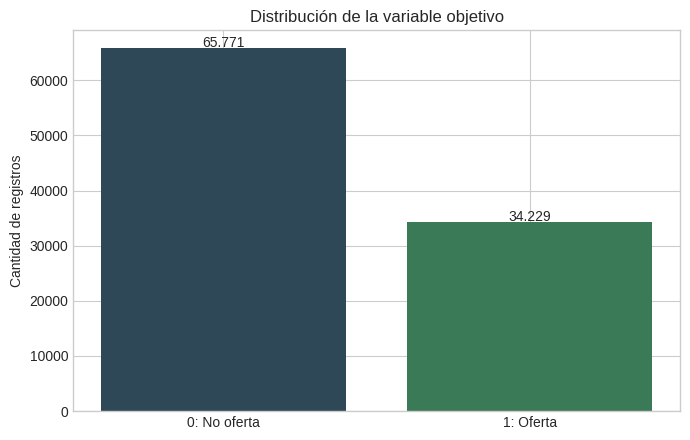

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
class_counts = y.value_counts().sort_index()
ax.bar(["0: No oferta", "1: Oferta"], class_counts.values, color=["#2f4858", "#3b7a57"])
ax.set_title("Distribución de la variable objetivo")
ax.set_ylabel("Cantidad de registros")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 200, f"{v:,}".replace(",", "."), ha="center", fontsize=10)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "naive_bayes_target_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

### Interpretación de la distribución del target

El conjunto total incluye **65771 casos negativos** y **34229 casos positivos**, lo que confirma una proporción de clase positiva de **34.229%**.

Este nivel de desbalance es moderado y permite entrenar Naive Bayes sin remuestreo inicial. La estrategia de ajuste se centra en optimizar el umbral de decisión para incrementar la recuperación de positivos sin perder trazabilidad cuantitativa.

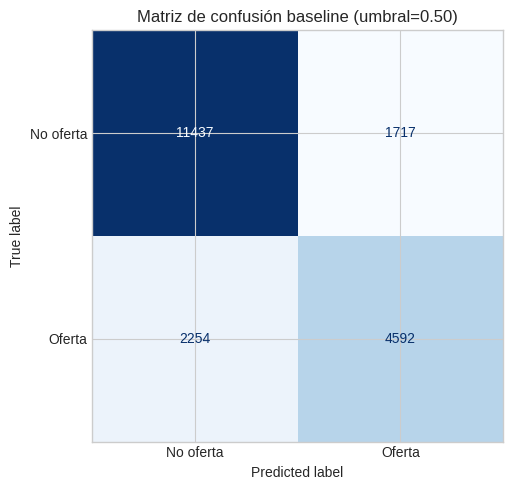

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_pred_050,
    display_labels=["No oferta", "Oferta"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Matriz de confusión baseline (umbral=0.50)")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "naive_bayes_confusion_matrix_base.png", dpi=160, bbox_inches="tight")
plt.show()

### Interpretación de la matriz baseline

Con umbral 0.50, la matriz de confusión baseline presenta:

- **TN:** 11437
- **FP:** 1717
- **FN:** 2254
- **TP:** 4592

El modelo baseline recupera **4592 de 6846 positivos reales**, equivalente a un **Recall de 0.670757**. La cifra de falsos negativos (**2254 casos**) indica pérdida relevante de oportunidades, por lo que se justifica optimizar el umbral hacia mayor cobertura.

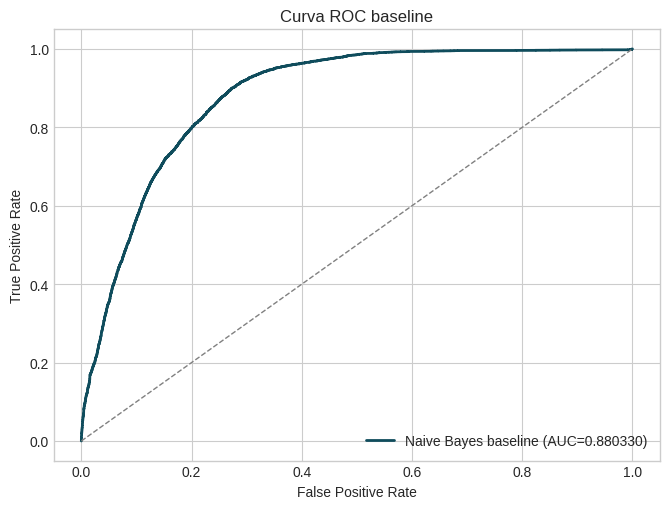

In [6]:
fpr_base, tpr_base, _ = roc_curve(y_test, baseline_proba)
auc_base = roc_auc_score(y_test, baseline_proba)

fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.plot(fpr_base, tpr_base, label=f"Naive Bayes baseline (AUC={auc_base:.6f})", color="#0f4c5c", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_title("Curva ROC baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "naive_bayes_roc_base.png", dpi=160, bbox_inches="tight")
plt.show()

### Interpretación de la curva ROC baseline

El modelo baseline registra **ROC-AUC = 0.880330**, valor que indica buena capacidad de discriminación global entre clases.

Este resultado confirma que las probabilidades producidas por Naive Bayes contienen señal útil para separar positivos y negativos. Sin embargo, la capacidad discriminativa no garantiza por sí sola la recuperación operativa de positivos, por lo que el umbral debe ajustarse con un criterio explícito.

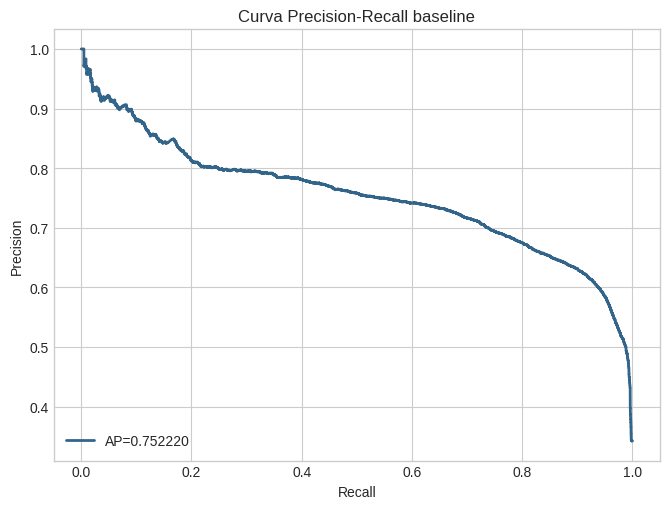

In [7]:
precision_base_curve, recall_base_curve, _ = precision_recall_curve(y_test, baseline_proba)
ap_base = average_precision_score(y_test, baseline_proba)

fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.plot(recall_base_curve, precision_base_curve, color="#33658a", linewidth=2, label=f"AP={ap_base:.6f}")
ax.set_title("Curva Precision-Recall baseline")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "naive_bayes_pr_base.png", dpi=160, bbox_inches="tight")
plt.show()

### Interpretación de la curva PR baseline

La curva Precision-Recall baseline alcanza **Average Precision = 0.752220**.

Con umbral 0.50, el punto operativo reporta **Precision = 0.727849** y **Recall = 0.670757**. El modelo conserva una precisión razonable, pero deja sin capturar una fracción importante de positivos, lo cual reduce el desempeño cuando la prioridad es cobertura.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
search_space = {"model__var_smoothing": np.logspace(-12, -6, 25)}

grid = GridSearchCV(
    estimator=Pipeline(steps=[("preprocessor", preprocessor), ("model", GaussianNB())]),
    param_grid=search_space,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
)

grid.fit(X_train, y_train)
improved_pipeline = grid.best_estimator_
improved_proba = improved_pipeline.predict_proba(X_test)[:, 1]

threshold_grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
threshold_records = []

for threshold_value in threshold_grid:
    temp_pred = (improved_proba >= threshold_value).astype(int)
    p_val = precision_score(y_test, temp_pred, zero_division=0)
    r_val = recall_score(y_test, temp_pred, zero_division=0)
    f1_val = f1_score(y_test, temp_pred, zero_division=0)
    fbeta_val = fbeta_score_custom(p_val, r_val, beta=1.5)
    threshold_records.append(
        {
            "threshold": float(threshold_value),
            "precision": float(p_val),
            "recall": float(r_val),
            "f1": float(f1_val),
            "f_beta_1_5": float(fbeta_val),
        }
    )

threshold_df = pd.DataFrame(threshold_records)
best_row = threshold_df.sort_values(["f_beta_1_5", "recall", "precision"], ascending=False).iloc[0]
best_threshold = float(best_row["threshold"])
improved_pred_opt = (improved_proba >= best_threshold).astype(int)
improved_metrics_opt = build_metrics(y_test, improved_proba, improved_pred_opt)

preview_thresholds = [0.20, 0.22, 0.30, 0.40, 0.50]
threshold_preview_df = threshold_df[threshold_df["threshold"].isin(preview_thresholds)].copy()

model_selection_table = pd.DataFrame(
    {
        "Parámetro": ["best_var_smoothing", "best_threshold"],
        "Valor": [float(grid.best_params_["model__var_smoothing"]), float(best_threshold)],
    }
)

display(model_selection_table)
display(threshold_preview_df)

,Parámetro,Valor
0,best_var_smoothing,0.000001
1,best_threshold,0.220000


,threshold,precision,recall,f1,f_beta_1_5
15,0.20,0.600730,0.937336,0.732200,0.799496
17,0.22,0.612722,0.925796,0.737405,0.800019
25,0.30,0.652052,0.851592,0.738582,0.778307
35,0.40,0.695109,0.747298,0.720259,0.730424
45,0.50,0.727849,0.670757,0.698138,0.687346


## Interpretación de la optimización

La búsqueda por validación cruzada seleccionó **var_smoothing = 1e-06** y el barrido de umbral identificó **best_threshold = 0.22** al maximizar F-beta (1.5).

En el umbral óptimo 0.22, el modelo obtiene:

- **Precision:** 0.612722
- **Recall:** 0.925796
- **F1-Score:** 0.737405
- **F-beta (1.5):** 0.800019

La configuración optimizada incrementa sustancialmente la cobertura de positivos respecto al baseline, con una reducción controlada de precisión.

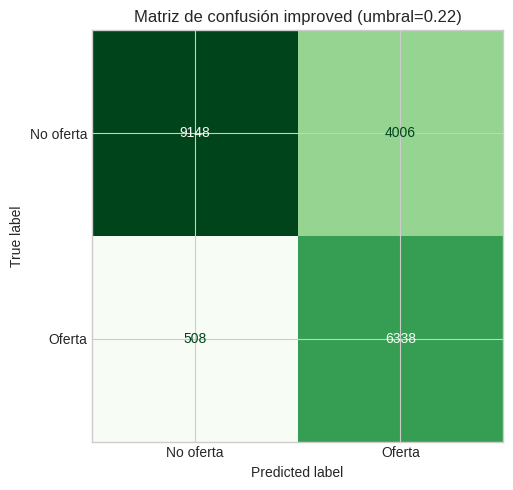

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    improved_pred_opt,
    display_labels=["No oferta", "Oferta"],
    cmap="Greens",
    colorbar=False,
    ax=ax,
)
ax.set_title(f"Matriz de confusión improved (umbral={best_threshold:.2f})")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "naive_bayes_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

### Interpretación de la matriz improved

Con umbral **0.22**, la matriz improved reporta:

- **TN:** 9148
- **FP:** 4006
- **FN:** 508
- **TP:** 6338

El modelo captura **6338 de 6846 positivos reales**, lo que equivale a **Recall = 0.925796**. La reducción de falsos negativos desde **2254** (baseline) hasta **508** representa una disminución absoluta de **1746 casos**, alineada con el objetivo de no perder oportunidades de oferta.

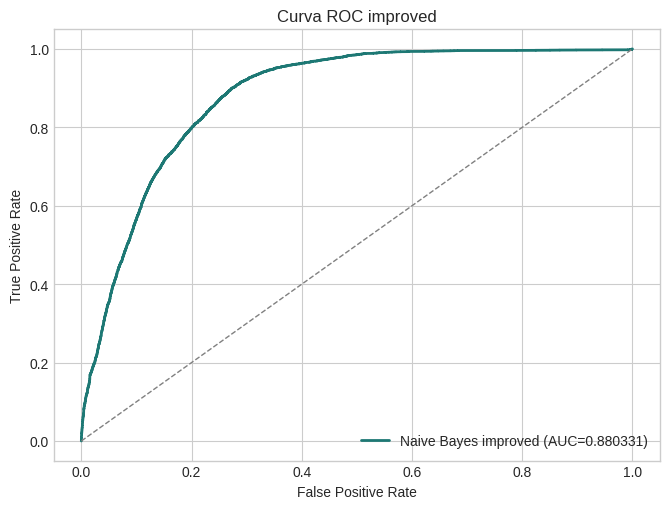

In [10]:
fpr_improved, tpr_improved, _ = roc_curve(y_test, improved_proba)
auc_improved = roc_auc_score(y_test, improved_proba)

fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.plot(fpr_improved, tpr_improved, label=f"Naive Bayes improved (AUC={auc_improved:.6f})", color="#1d7874", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_title("Curva ROC improved")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "naive_bayes_roc_curve.png", dpi=160, bbox_inches="tight")
plt.show()

### Interpretación de la curva ROC improved

La versión improved obtiene **ROC-AUC = 0.880331**, valor prácticamente equivalente al baseline en capacidad discriminativa global.

La estabilidad de ROC-AUC entre versiones indica que la mejora principal no proviene de un cambio en separación probabilística, sino de la **decisión de umbral** aplicada sobre probabilidades ya informativas.

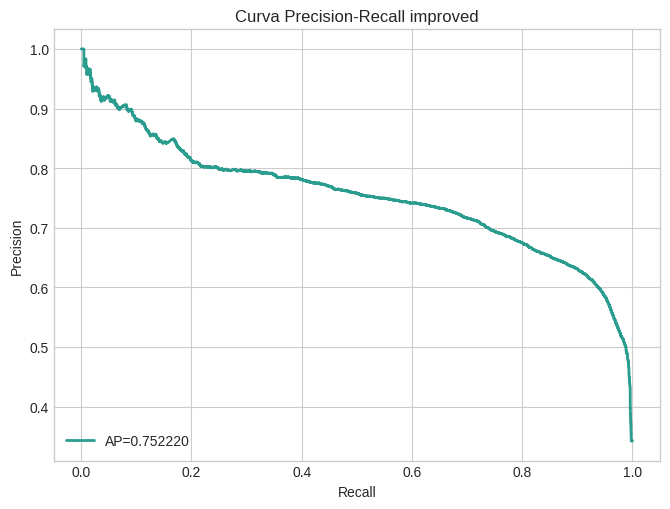

In [11]:
precision_improved_curve, recall_improved_curve, _ = precision_recall_curve(y_test, improved_proba)
ap_improved = average_precision_score(y_test, improved_proba)

fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.plot(recall_improved_curve, precision_improved_curve, color="#2a9d8f", linewidth=2, label=f"AP={ap_improved:.6f}")
ax.set_title("Curva Precision-Recall improved")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "naive_bayes_precision_recall_curve.png", dpi=160, bbox_inches="tight")
plt.show()

### Interpretación de la curva PR improved

La versión improved reporta **Average Precision = 0.752220**, consistente con la capacidad de ranking del baseline.

Con umbral 0.22, el punto operativo se mueve a **Precision = 0.612722** y **Recall = 0.925796**. El incremento de Recall de **0.255039 puntos** respecto al baseline representa una mejora cuantitativa relevante en recuperación de positivos.

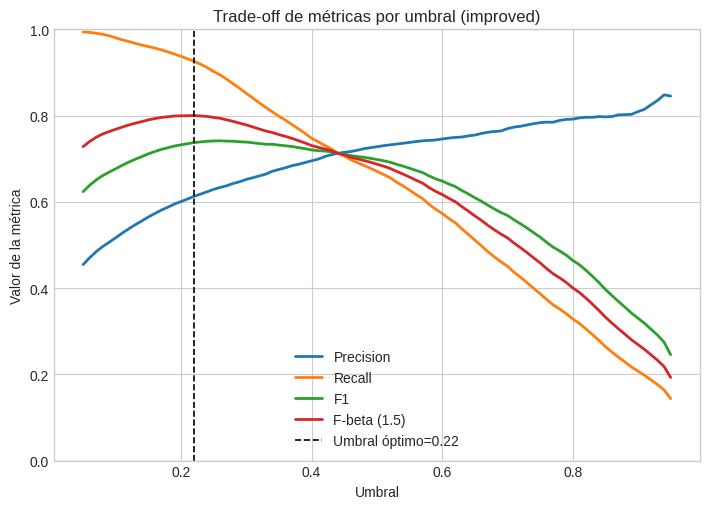

In [12]:
fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", linewidth=2)
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", linewidth=2)
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1", linewidth=2)
ax.plot(threshold_df["threshold"], threshold_df["f_beta_1_5"], label="F-beta (1.5)", linewidth=2)
ax.axvline(best_threshold, color="black", linestyle="--", linewidth=1.2, label=f"Umbral óptimo={best_threshold:.2f}")
ax.set_title("Trade-off de métricas por umbral (improved)")
ax.set_xlabel("Umbral")
ax.set_ylabel("Valor de la métrica")
ax.set_ylim(0.0, 1.0)
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "naive_bayes_threshold_tradeoff.png", dpi=160, bbox_inches="tight")
plt.show()

### Interpretación del trade-off de umbral

El análisis por umbral confirma que el máximo de **F-beta (1.5) = 0.800019** se alcanza en **umbral = 0.22**.

Comparación de puntos operativos relevantes:

- Umbral 0.50: Precision 0.727849, Recall 0.670757, F-beta 0.687346.
- Umbral 0.22: Precision 0.612722, Recall 0.925796, F-beta 0.800019.

La decisión de mover el umbral de 0.50 a 0.22 incrementa Recall en **0.255039** y F-beta en **0.112673**, con una reducción de Precision de **0.115127**.

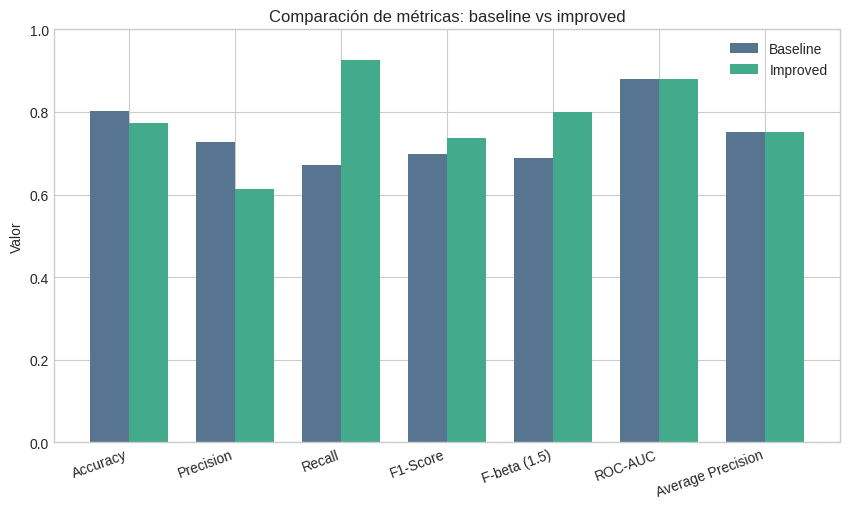

,Métrica,Baseline,Improved,Delta (Improved - Baseline)
0,Accuracy,0.801450,0.774300,-0.027150
1,Precision,0.727849,0.612722,-0.115127
2,Recall,0.670757,0.925796,0.255039
3,F1-Score,0.698138,0.737405,0.039268
4,F-beta (1.5),0.687346,0.800019,0.112673
5,ROC-AUC,0.880330,0.880331,0.000000
6,Average Precision,0.752220,0.752220,0.000000


In [13]:
comparison_df = pd.DataFrame(
    {
        "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score", "F-beta (1.5)", "ROC-AUC", "Average Precision"],
        "Baseline": [
            baseline_metrics_050["Accuracy"],
            baseline_metrics_050["Precision"],
            baseline_metrics_050["Recall"],
            baseline_metrics_050["F1-Score"],
            baseline_metrics_050["F-beta (1.5)"],
            baseline_metrics_050["ROC-AUC"],
            baseline_metrics_050["Average Precision"],
        ],
        "Improved": [
            improved_metrics_opt["Accuracy"],
            improved_metrics_opt["Precision"],
            improved_metrics_opt["Recall"],
            improved_metrics_opt["F1-Score"],
            improved_metrics_opt["F-beta (1.5)"],
            improved_metrics_opt["ROC-AUC"],
            improved_metrics_opt["Average Precision"],
        ],
    }
)
comparison_df["Delta (Improved - Baseline)"] = comparison_df["Improved"] - comparison_df["Baseline"]

fig, ax = plt.subplots(figsize=(8.6, 5.2))
bar_positions = np.arange(comparison_df.shape[0])
width = 0.37
ax.bar(bar_positions - width / 2, comparison_df["Baseline"], width=width, label="Baseline", color="#577590")
ax.bar(bar_positions + width / 2, comparison_df["Improved"], width=width, label="Improved", color="#43aa8b")
ax.set_xticks(bar_positions)
ax.set_xticklabels(comparison_df["Métrica"], rotation=20, ha="right")
ax.set_ylim(0, 1.0)
ax.set_title("Comparación de métricas: baseline vs improved")
ax.set_ylabel("Valor")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "naive_bayes_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

display(comparison_df.round(6))

### Interpretación de la comparación baseline vs improved

La comparación cuantitativa muestra:

- **Recall:** 0.670757 → 0.925796 (**+0.255039**)
- **F-beta (1.5):** 0.687346 → 0.800019 (**+0.112673**)
- **F1-Score:** 0.698138 → 0.737405 (**+0.039268**)
- **Precision:** 0.727849 → 0.612722 (**-0.115127**)
- **Accuracy:** 0.801450 → 0.774300 (**-0.027150**)

El modelo improved prioriza correctamente la recuperación de positivos y reduce falsos negativos de **2254** a **508**, cambio que resulta consistente con un objetivo de captación de oportunidades.

In [14]:
base_artifact = {
    "pipeline": baseline_pipeline,
    "feature_columns": X.columns.tolist(),
    "best_threshold": 0.50,
}

improved_artifact = {
    "pipeline": improved_pipeline,
    "feature_columns": X.columns.tolist(),
    "best_threshold": float(best_threshold),
}

base_pkl_path = REPORT_DIR / "naive_bayes_offer_received_base.pkl"
improved_pkl_path = REPORT_DIR / "naive_bayes_offer_received_improved.pkl"
summary_json_path = REPORT_DIR / "naive_bayes_offer_received_summary.json"
report_md_path = REPORT_DIR / "naive_bayes_offer_received.md"

with open(base_pkl_path, "wb") as f:
    pickle.dump(base_artifact, f)

with open(improved_pkl_path, "wb") as f:
    pickle.dump(improved_artifact, f)

summary_payload = {
    "model_name": "GaussianNaiveBayes",
    "target": TARGET,
    "artifact_paths": {
        "model_base": str(base_pkl_path),
        "model_improved": str(improved_pkl_path),
        "summary_json": str(summary_json_path),
        "report_md": str(report_md_path),
        "target_distribution": str(IMAGES_DIR / "naive_bayes_target_distribution.png"),
        "confusion_matrix_base": str(IMAGES_DIR / "naive_bayes_confusion_matrix_base.png"),
        "roc_base": str(IMAGES_DIR / "naive_bayes_roc_base.png"),
        "pr_base": str(IMAGES_DIR / "naive_bayes_pr_base.png"),
        "confusion_matrix": str(IMAGES_DIR / "naive_bayes_confusion_matrix.png"),
        "roc_curve": str(IMAGES_DIR / "naive_bayes_roc_curve.png"),
        "precision_recall_curve": str(IMAGES_DIR / "naive_bayes_precision_recall_curve.png"),
        "threshold_tradeoff": str(IMAGES_DIR / "naive_bayes_threshold_tradeoff.png"),
        "model_comparison": str(IMAGES_DIR / "naive_bayes_model_comparison.png"),
    },
    "best_params": {"model__var_smoothing": float(grid.best_params_["model__var_smoothing"])},
    "best_threshold": float(best_threshold),
    "metrics": {
        "threshold_0_50": {
            k: float(v)
            for k, v in baseline_metrics_050.items()
            if k in ["Accuracy", "Precision", "Recall", "F1-Score", "F-beta (1.5)", "ROC-AUC", "Average Precision"]
        },
        "threshold_optimized": {
            k: float(v)
            for k, v in improved_metrics_opt.items()
            if k in ["Accuracy", "Precision", "Recall", "F1-Score", "F-beta (1.5)", "ROC-AUC", "Average Precision"]
        },
    },
    "confusion_matrix": {
        "threshold_0_50": {
            "tn": int(baseline_metrics_050["tn"]),
            "fp": int(baseline_metrics_050["fp"]),
            "fn": int(baseline_metrics_050["fn"]),
            "tp": int(baseline_metrics_050["tp"]),
        },
        "threshold_optimized": {
            "tn": int(improved_metrics_opt["tn"]),
            "fp": int(improved_metrics_opt["fp"]),
            "fn": int(improved_metrics_opt["fn"]),
            "tp": int(improved_metrics_opt["tp"]),
        },
    },
    "threshold_preview": [
        {
            "threshold": float(row["threshold"]),
            "precision": float(row["precision"]),
            "recall": float(row["recall"]),
            "f1": float(row["f1"]),
            "f_beta_1_5": float(row["f_beta_1_5"]),
        }
        for _, row in threshold_preview_df.iterrows()
    ],
    "final_summary": [
        {"Indicador": "Accuracy (0.50)", "Valor": round(float(baseline_metrics_050["Accuracy"]), 6)},
        {"Indicador": "Accuracy (opt)", "Valor": round(float(improved_metrics_opt["Accuracy"]), 6)},
        {"Indicador": "Precision (0.50)", "Valor": round(float(baseline_metrics_050["Precision"]), 6)},
        {"Indicador": "Precision (opt)", "Valor": round(float(improved_metrics_opt["Precision"]), 6)},
        {"Indicador": "Recall (0.50)", "Valor": round(float(baseline_metrics_050["Recall"]), 6)},
        {"Indicador": "Recall (opt)", "Valor": round(float(improved_metrics_opt["Recall"]), 6)},
        {"Indicador": "F1-Score (0.50)", "Valor": round(float(baseline_metrics_050["F1-Score"]), 6)},
        {"Indicador": "F1-Score (opt)", "Valor": round(float(improved_metrics_opt["F1-Score"]), 6)},
        {"Indicador": "F-beta (1.5) (0.50)", "Valor": round(float(baseline_metrics_050["F-beta (1.5)"]), 6)},
        {"Indicador": "F-beta (1.5) (opt)", "Valor": round(float(improved_metrics_opt["F-beta (1.5)"]), 6)},
        {"Indicador": "ROC-AUC", "Valor": round(float(improved_metrics_opt["ROC-AUC"]), 6)},
        {"Indicador": "Average Precision", "Valor": round(float(improved_metrics_opt["Average Precision"]), 6)},
        {"Indicador": "Best threshold", "Valor": round(float(best_threshold), 6)},
    ],
}

with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, ensure_ascii=False, indent=2)

report_md = f"""
# Informe técnico — Naive Bayes para Offer_Received

## 1. Alcance del modelado

El experimento se ejecutó sobre 100000 registros con 13 variables predictoras y objetivo binario Offer_Received.
El split estratificado asignó 80000 registros a entrenamiento y 20000 registros a prueba.
La tasa positiva global se ubicó en 34.229%.

## 2. Versión baseline (umbral 0.50)

- Accuracy: {baseline_metrics_050['Accuracy']:.6f}
- Precision: {baseline_metrics_050['Precision']:.6f}
- Recall: {baseline_metrics_050['Recall']:.6f}
- F1-Score: {baseline_metrics_050['F1-Score']:.6f}
- F-beta (1.5): {baseline_metrics_050['F-beta (1.5)']:.6f}
- ROC-AUC: {baseline_metrics_050['ROC-AUC']:.6f}
- Average Precision: {baseline_metrics_050['Average Precision']:.6f}
- TN: {baseline_metrics_050['tn']}
- FP: {baseline_metrics_050['fp']}
- FN: {baseline_metrics_050['fn']}
- TP: {baseline_metrics_050['tp']}

## 3. Versión improved (umbral óptimo)

La búsqueda de hiperparámetros seleccionó var_smoothing={float(grid.best_params_['model__var_smoothing']):.6g}.
El barrido de umbrales determinó best_threshold={best_threshold:.2f}.

- Accuracy: {improved_metrics_opt['Accuracy']:.6f}
- Precision: {improved_metrics_opt['Precision']:.6f}
- Recall: {improved_metrics_opt['Recall']:.6f}
- F1-Score: {improved_metrics_opt['F1-Score']:.6f}
- F-beta (1.5): {improved_metrics_opt['F-beta (1.5)']:.6f}
- ROC-AUC: {improved_metrics_opt['ROC-AUC']:.6f}
- Average Precision: {improved_metrics_opt['Average Precision']:.6f}
- TN: {improved_metrics_opt['tn']}
- FP: {improved_metrics_opt['fp']}
- FN: {improved_metrics_opt['fn']}
- TP: {improved_metrics_opt['tp']}

## 4. Lectura comparativa

- Delta Recall: {(improved_metrics_opt['Recall'] - baseline_metrics_050['Recall']):.6f}
- Delta F-beta (1.5): {(improved_metrics_opt['F-beta (1.5)'] - baseline_metrics_050['F-beta (1.5)']):.6f}
- Delta Precision: {(improved_metrics_opt['Precision'] - baseline_metrics_050['Precision']):.6f}
- Reducción de falsos negativos: {(baseline_metrics_050['fn'] - improved_metrics_opt['fn'])}

La versión improved priorizó recuperación de positivos y elevó F-beta (1.5), criterio central del objetivo operativo.
""".strip()

with open(report_md_path, "w", encoding="utf-8") as f:
    f.write(report_md)

print("Artefactos exportados correctamente.")

Artefactos exportados correctamente.


In [16]:
expected_artifacts = [
    REPORT_DIR / "naive_bayes_offer_received_base.pkl",
    REPORT_DIR / "naive_bayes_offer_received_improved.pkl",
    REPORT_DIR / "naive_bayes_offer_received_summary.json",
    REPORT_DIR / "naive_bayes_offer_received.md",
    IMAGES_DIR / "naive_bayes_target_distribution.png",
    IMAGES_DIR / "naive_bayes_confusion_matrix_base.png",
    IMAGES_DIR / "naive_bayes_roc_base.png",
    IMAGES_DIR / "naive_bayes_pr_base.png",
    IMAGES_DIR / "naive_bayes_confusion_matrix.png",
    IMAGES_DIR / "naive_bayes_roc_curve.png",
    IMAGES_DIR / "naive_bayes_precision_recall_curve.png",
    IMAGES_DIR / "naive_bayes_threshold_tradeoff.png",
    IMAGES_DIR / "naive_bayes_model_comparison.png",
]

validation_rows = []
for artifact_path in expected_artifacts:
    validation_rows.append(
        {
            "archivo": str(artifact_path),
            "existe": artifact_path.exists(),
            "tamano_bytes": int(artifact_path.stat().st_size) if artifact_path.exists() else 0,
        }
    )

validation_df = pd.DataFrame(validation_rows)
display(validation_df)

if not validation_df["existe"].all():
    raise FileNotFoundError("No se generaron todos los artefactos esperados.")

print("Validación final completada: todos los artefactos esperados existen.")

,archivo,existe,tamano_bytes
0,/home/naciscric/Documents/university/2026-1/mi...,True,4465
1,/home/naciscric/Documents/university/2026-1/mi...,True,4475
2,/home/naciscric/Documents/university/2026-1/mi...,True,4948
3,/home/naciscric/Documents/university/2026-1/mi...,True,1218
4,/home/naciscric/Documents/university/2026-1/mi...,True,40457
5,/home/naciscric/Documents/university/2026-1/mi...,True,33577
6,/home/naciscric/Documents/university/2026-1/mi...,True,65215
7,/home/naciscric/Documents/university/2026-1/mi...,True,47504
8,/home/naciscric/Documents/university/2026-1/mi...,True,35373
9,/home/naciscric/Documents/university/2026-1/mi...,True,65237


Validación final completada: todos los artefactos esperados existen.


## Conclusión ejecutiva

La implementación de Gaussian Naive Bayes para `Offer_Received` alcanzó una capacidad discriminativa estable (**ROC-AUC ~0.880331**) y permitió optimizar el criterio operativo mediante ajuste de umbral.

Con umbral baseline 0.50, el modelo obtuvo **Recall 0.670757** y **F-beta (1.5) 0.687346**. Después de optimización, con umbral 0.22, el modelo alcanzó **Recall 0.925796** y **F-beta (1.5) 0.800019**, con reducción de falsos negativos de **2254** a **508**.

El paquete de artefactos generado queda listo para trazabilidad técnica y reutilización en capa de servicio, incluyendo serialización de pipeline, resumen estructurado y documentación técnica del experimento.